<a href="https://colab.research.google.com/github/dhans2007/ML_LAB/blob/main/ML_EXP_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DHANESH VC 24BAD018
EXPERIMENT-06

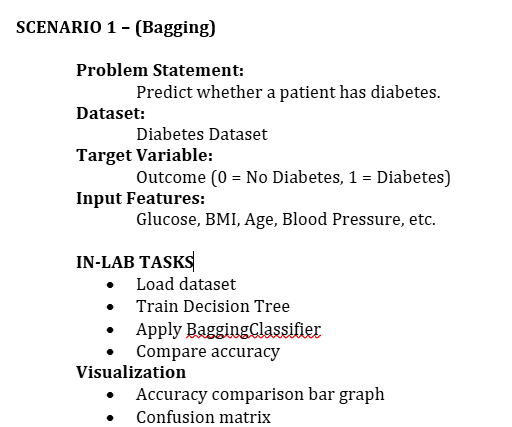

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

#DHANESH VC 24BAD018
#Load dataset
df = pd.read_csv('diabetes_bagging.csv')
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train Decision Tree (Base Model)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))

#Apply BaggingClassifier
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bagging.fit(X_train, y_train)
bagging_acc = accuracy_score(y_test, bagging.predict(X_test))


Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


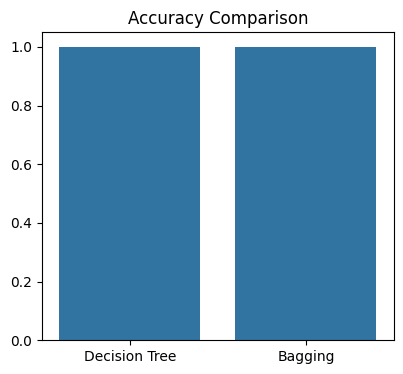

In [48]:
#Visualization
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=['Decision Tree', 'Bagging'], y=[dt_acc, bagging_acc])
plt.title('Accuracy Comparison')
print("Decision Tree Accuracy:", dt_acc)
print("Bagging Accuracy:", bagging_acc)

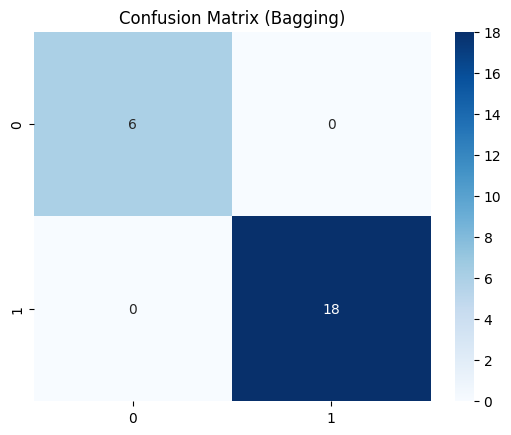

In [49]:

sns.heatmap(confusion_matrix(y_test, bagging.predict(X_test)), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Bagging)')
plt.show()

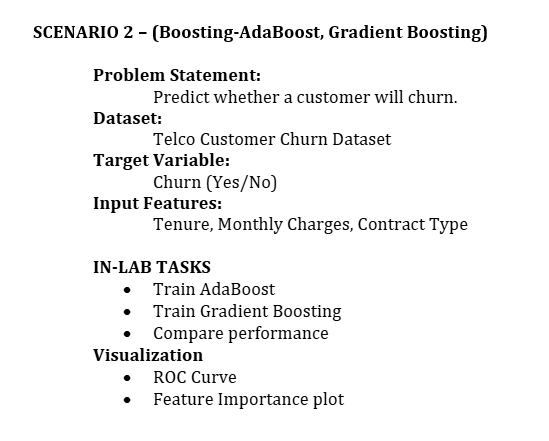

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder

print("Scenario 2")
#Load and Preprocess
df = pd.read_csv('churn_boosting.csv')
le = LabelEncoder()
for col in ['ContractType', 'InternetService']:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train Models
ada = AdaBoostClassifier(n_estimators=50, random_state=42).fit(X_train, y_train)
gb = GradientBoostingClassifier(n_estimators=50, random_state=42).fit(X_train, y_train)


Scenario 2


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


Text(0.5, 1.0, 'ROC Curve')

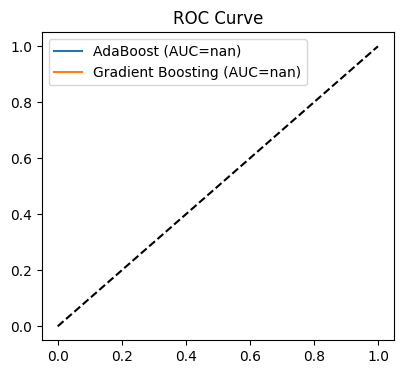

In [51]:
#Visualization: ROC Curve
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
for model, name in [(ada, 'AdaBoost'), (gb, 'Gradient Boosting')]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.2f})')
plt.plot([0,1],[0,1], 'k--')
plt.legend()
plt.title('ROC Curve')

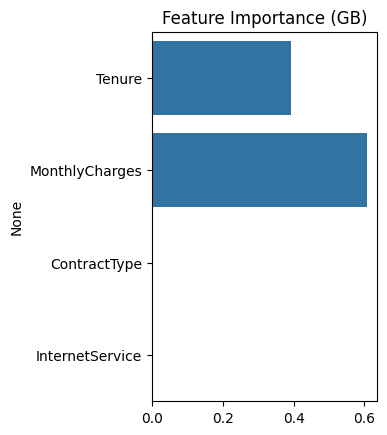

In [52]:

#Feature Importance
plt.subplot(1, 2, 2)
sns.barplot(x=gb.feature_importances_, y=X.columns)
plt.title('Feature Importance (GB)')
plt.show()

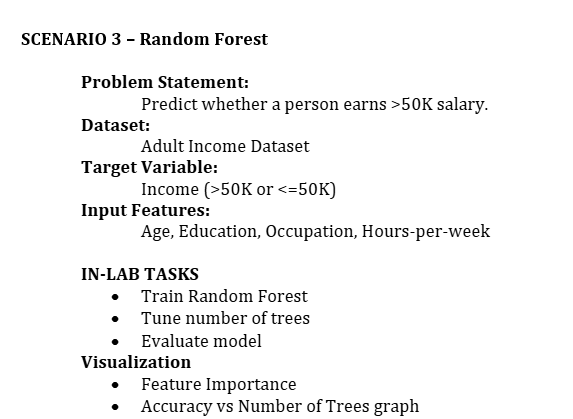

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Scenario 3")

df = pd.read_csv('income_random_forest.csv')
X = df.drop('Income', axis=1)
y = df['Income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Tune Number of Trees
tree_counts = [10, 50, 100, 200]
accuracies = []
for n in tree_counts:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, rf.predict(X_test)))


Scenario 3


Text(0.5, 1.0, 'Feature Importance')

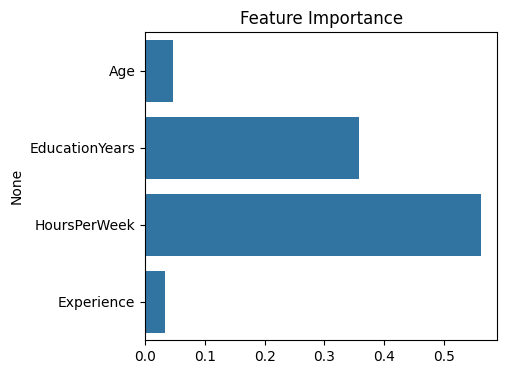

In [54]:
#Visualization
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=rf.feature_importances_, y=X.columns)
plt.title('Feature Importance')

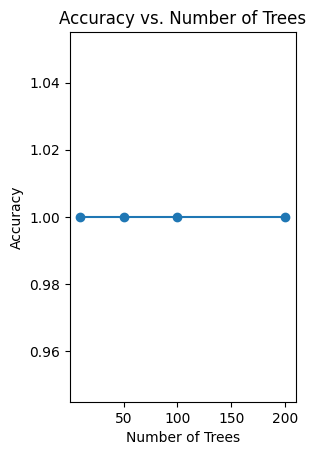

In [55]:
plt.subplot(1, 2, 2)
plt.plot(tree_counts, accuracies, marker='o')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Trees')
plt.show()

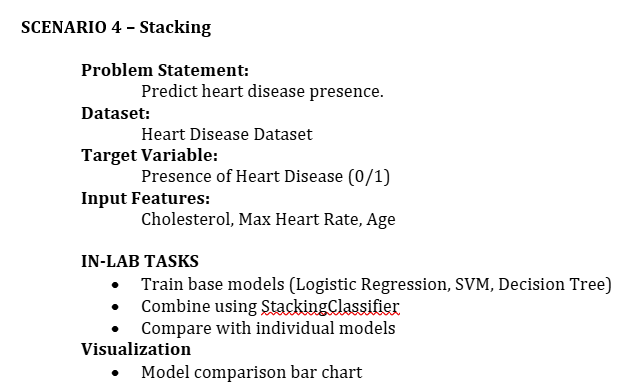

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier

print("Scenario 4")

df = pd.read_csv('heart_stacking.csv')
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Define Base Models and Stacking
base_models = [('LR', LogisticRegression(max_iter=1000)),
               ('SVM', SVC(probability=True)),
               ('DT', DecisionTreeClassifier())]
stacking = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())
stacking.fit(X_train, y_train)

#Compare Performance
results = {}
for name, model in base_models + [('Stacking', stacking)]:
    model.fit(X_train, y_train)
    results[name] = accuracy_score(y_test, model.predict(X_test))


Scenario 4


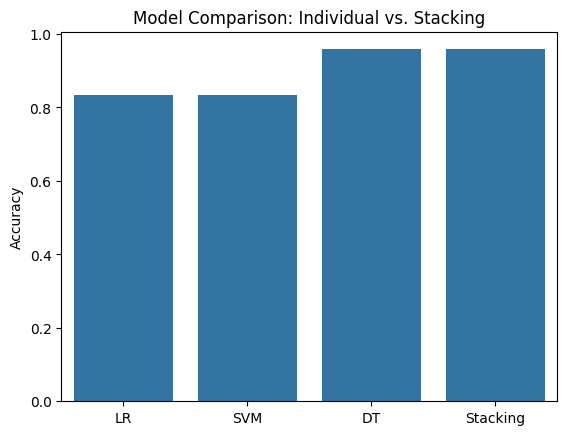

In [57]:
# 4. Visualization
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylabel('Accuracy')
plt.title('Model Comparison: Individual vs. Stacking')
plt.show()

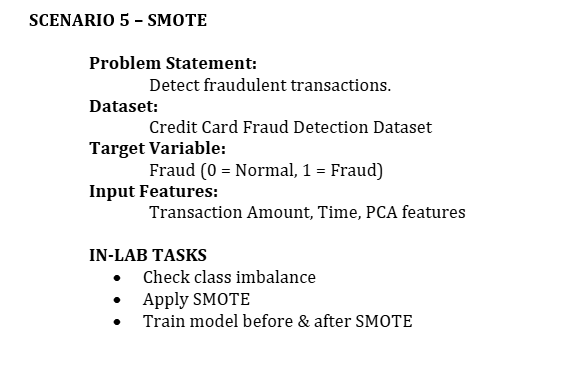

In [58]:
# Apply SMOTE and compare model performance
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

print("Scenario 5")

df = pd.read_csv('fraud_smote.csv')
X = df.drop('Fraud', axis=1)
y = df['Fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# Train models
clf_before = RandomForestClassifier(n_estimators=50, random_state=42)
clf_before.fit(X_train, y_train)

clf_after = RandomForestClassifier(n_estimators=50, random_state=42)
clf_after.fit(X_res, y_res)

# Accuracy comparison
print("Before SMOTE Accuracy:", accuracy_score(y_test, clf_before.predict(X_test)))
print("After SMOTE Accuracy:", accuracy_score(y_test, clf_after.predict(X_test)))

# Class distribution
print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_res.value_counts())


Scenario 5
Before SMOTE Accuracy: 0.9166666666666666
After SMOTE Accuracy: 0.8333333333333334
Before SMOTE:
 Fraud
0    88
1     8
Name: count, dtype: int64
After SMOTE:
 Fraud
1    88
0    88
Name: count, dtype: int64


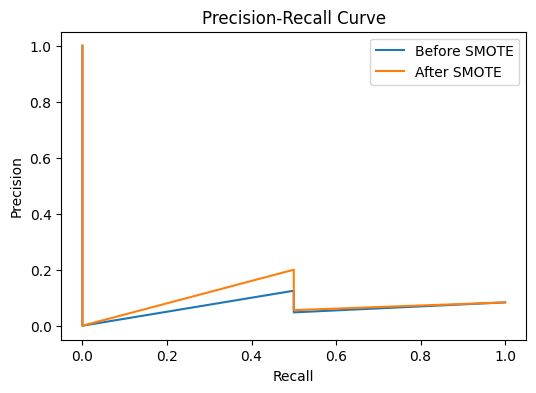

In [59]:
#Visualization: Precision-Recall Curve
plt.figure(figsize=(6, 4))
for model, label in [(clf_before, 'Before SMOTE'), (clf_after, 'After SMOTE')]:
    probs = model.predict_proba(X_test)[:, 1]
    p, r, _ = precision_recall_curve(y_test, probs)
    plt.plot(r, p, label=label)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.title('Precision-Recall Curve')
plt.show()